In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression,Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import KFold, GridSearchCV
from xgboost import XGBRegressor
from scipy import stats
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, recall_score, accuracy_score

Question 1 – Communities & Crime

In [12]:
col_names = [
    'state', 'county', 'community', 'communityname', 'fold', 'population', 'householdsize',
    'racepctblack', 'racePctWhite', 'racePctAsian', 'racePctHisp', 'agePct12t21',
    'agePct12t29', 'agePct16t24', 'agePct65up', 'numbUrban', 'pctUrban', 'medIncome',
    'pctWWage', 'pctWFarmSelf', 'pctWInvInc', 'pctWSocSec', 'pctWPubAsst', 'pctWRetire',
    'medFamInc', 'perCapInc', 'whitePerCap', 'blackPerCap', 'indianPerCap', 'AsianPerCap',
    'OtherPerCap', 'HispPerCap', 'NumUnderPov', 'PctPopUnderPov', 'PctLess9thGrade',
    'PctNotHSGrad', 'PctBSorMore', 'PctUnemployed', 'PctEmploy', 'PctEmplManu',
    'PctEmplProfServ', 'PctOccupManu', 'PctOccupMgmtProf', 'MalePctDivorce',
    'MalePctNevMarr', 'FemalePctDiv', 'TotalPctDiv', 'PersPerFam', 'PctFam2Par',
    'PctKids2Par', 'PctYoungKids2Par', 'PctTeen2Par', 'PctWorkMomYoungKids', 'PctWorkMom',
    'NumIlleg', 'PctIlleg', 'NumImmig', 'PctImmigRecent', 'PctImmigRec5', 'PctImmigRec8',
    'PctImmigRec10', 'PctRecentImmig', 'PctRecImmig5', 'PctRecImmig8', 'PctRecImmig10',
    'PctSpeakEnglOnly', 'PctNotSpeakEnglWell', 'PctLargHouseFam', 'PctLargHouseOccup',
    'PersPerOccupHous', 'PersPerOwnOccHous', 'PersPerRentOccHous', 'PctPersOwnOccup',
    'PctPersDenseHous', 'PctHousLess3BR', 'MedNumBR', 'HousVacant', 'PctHousOccup',
    'PctHousOwnOcc', 'PctVacantBoarded', 'PctVacMore6Mos', 'MedYrHousBuilt',
    'PctHousNoPhone', 'PctWOFullPlumb', 'OwnOccLowQuart', 'OwnOccMedVal', 'OwnOccHiQuart',
    'RentLowQ', 'RentMedian', 'RentHighQ', 'MedRent', 'MedRentPctHousInc',
    'MedOwnCostPctInc', 'MedOwnCostPctIncNoMtg', 'NumInShelters', 'NumStreet',
    'PctForeignBorn', 'PctBornSameState', 'PctSameHouse85', 'PctSameCity85',
    'PctSameState85', 'LemasSwornFT', 'LemasSwFTPerPop', 'LemasSwFTFieldOps',
    'LemasSwFTFieldPerPop', 'LemasTotalReq', 'LemasTotReqPerPop', 'PolicReqPerOffic',
    'PolicPerPop', 'RacialMatchCommPol', 'PctPolicWhite', 'PctPolicBlack',
    'PctPolicHisp', 'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits',
    'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'LandArea', 'PopDens', 'PctUsePubTrans',
    'PolicCars', 'PolicOperBudg', 'LemasPctPolicOnPatr', 'LemasGangUnitDeploy',
    'LemasPctOfficDrugUn', 'PolicBudgPerPop', 'ViolentCrimesPerPop'
]

df_original= pd.read_csv("data/communities.data", header=None, names=col_names)

In [3]:
df.head(10)

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03
5,6,?,?,SouthPasadenacity,1,0.02,0.28,0.06,0.54,1.00,...,0.01,0.58,0.10,?,?,?,?,0.00,?,0.14
6,44,7,41500,Lincolntown,1,0.01,0.39,0.00,0.98,0.06,...,0.05,0.08,0.06,?,?,?,?,0.00,?,0.03
7,6,?,?,Selmacity,1,0.01,0.74,0.03,0.46,0.20,...,0.01,0.33,0.00,?,?,?,?,0.00,?,0.55
8,21,?,?,Hendersoncity,1,0.03,0.34,0.20,0.84,0.02,...,0.04,0.17,0.04,?,?,?,?,0.00,?,0.53
9,29,?,?,Claytoncity,1,0.01,0.40,0.06,0.87,0.30,...,0.00,0.47,0.11,?,?,?,?,0.00,?,0.15


Task A: Dataset Curation and Preprocessing

1. potential shortcomings
1) The crime data is form 1995 while the demographc and law enforcement data is from 1990. five years gap could meant a lot, espeically experience change of elected officials.
2) For FBI UCR dataset, we may presume that the more dense the police force is the more likely the crime will be record into database.
3) the dataset itself had encounter many data selection bias, for example, some middle west communities are filtered out due to the distribution of rap crime data, also for Law Enforcement Management and Administration Statistics, agencies that have officer less than 100 is filter out. this means the model may not have the ability to predict these cases, and the interpret of the model also limited to the cases within the dataset.

2. preprocessing and explianations, as follows:

In [15]:
# copy the original dataframe to a new one, so that we do not have to reload the data when we want to try a different preprocessing method.
df = df_original.copy()

# drop duplicates.
df = df.drop_duplicates()

# drop useless columns, as they are not useful for our model.
df = df.drop(columns=['state', 'county', 'community', 'communityname', 'fold'])

# replace ? with NaN and make sure all columns are numeric.
df = df.replace('?', np.nan)
df = df.apply(pd.to_numeric, errors='coerce')

# filter out rows with missing target variable, as we cannot use them for training or testing our model.
df = df[df['ViolentCrimesPerPop'].notna()]

# only keep columsn with less than 50% missing values. There could be a better way to deal with them, but here we just drop them for simplicity.
df = df.loc[:, df.isnull().mean() < 0.5]

# split the data into features and target variable.
X = df.drop('ViolentCrimesPerPop', axis=1)
y = df['ViolentCrimesPerPop']
# here we split the data before impute with MICE, because we want to avoid data leakage. 
# If we impute the whole dataset before splitting, the imputation process will use information from the test set, 
# which can lead to overly optimistic performance estimates. By splitting the data first and then applying MICE separately to the training and test sets, 
# we ensure that the imputation process only uses information from the training set, thus providing a more realistic evaluation of our model's performance on unseen data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# outlier detection and treatment is put here, as we should only do operation on training set and avoiding operating on test set to prevent data leakage.
# here we use z-score to detect and replce outliers with NaN
z_scores = np.abs((X_train - X_train.mean()) / X_train.std())
X_train = X_train.mask(z_scores > 3, np.nan)

# handle missing value by imputing with MICE. MICE is a more sophisticated imputation method that models each feature with missing values as a function of other features, 
# and iteratively estimates the missing values. This can lead to more accurate imputations compared to simpler methods like mean or median imputation, 
# especially when the data has complex relationships between features.
imputer = IterativeImputer(add_indicator=True).set_output(transform="pandas")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# There is no need for feature scaling as the orignal dataset already did this for us.

/usr/lib/python3/dist-packages/sklearn/impute/_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


3. feature engineering three features:

In [17]:
# 1) we create an interation term of youth population and unemployemnt. we presume that the young unemployed people will have a huge effect on the crime rate.
X_train['Youth_Unemployment_Proxy'] = X_train['agePct16t24'] * X_train['PctUnemployed']

# 2) we create an interaction term of poverty and unemployment rate. we suspect that the poor people who are unemployed will have a higher crime rate.
X_train['Poverty_Unemployment_Proxy'] = X_train['PctPopUnderPov'] * X_train['PctUnemployed']

# 3) we create a squared term of the percentage of kids living with both parents, as we suspect that the effect of this variable on crime rate is not linear, 
# and there might be a threshold effect where the crime rate drops significantly when the percentage of kids living with both parents exceeds a certain level.
X_train['PctKids2Par_Squared'] = X_train['PctKids2Par'] ** 2

# applying these three features to test set.
X_test['Youth_Unemployment_Proxy'] = X_test['agePct16t24'] * X_test['PctUnemployed']
X_test['Poverty_Unemployment_Proxy'] = X_test['PctPopUnderPov'] * X_test['PctUnemployed']
X_test['PctKids2Par_Squared'] = X_test['PctKids2Par'] ** 2

4. Curate the processed data:

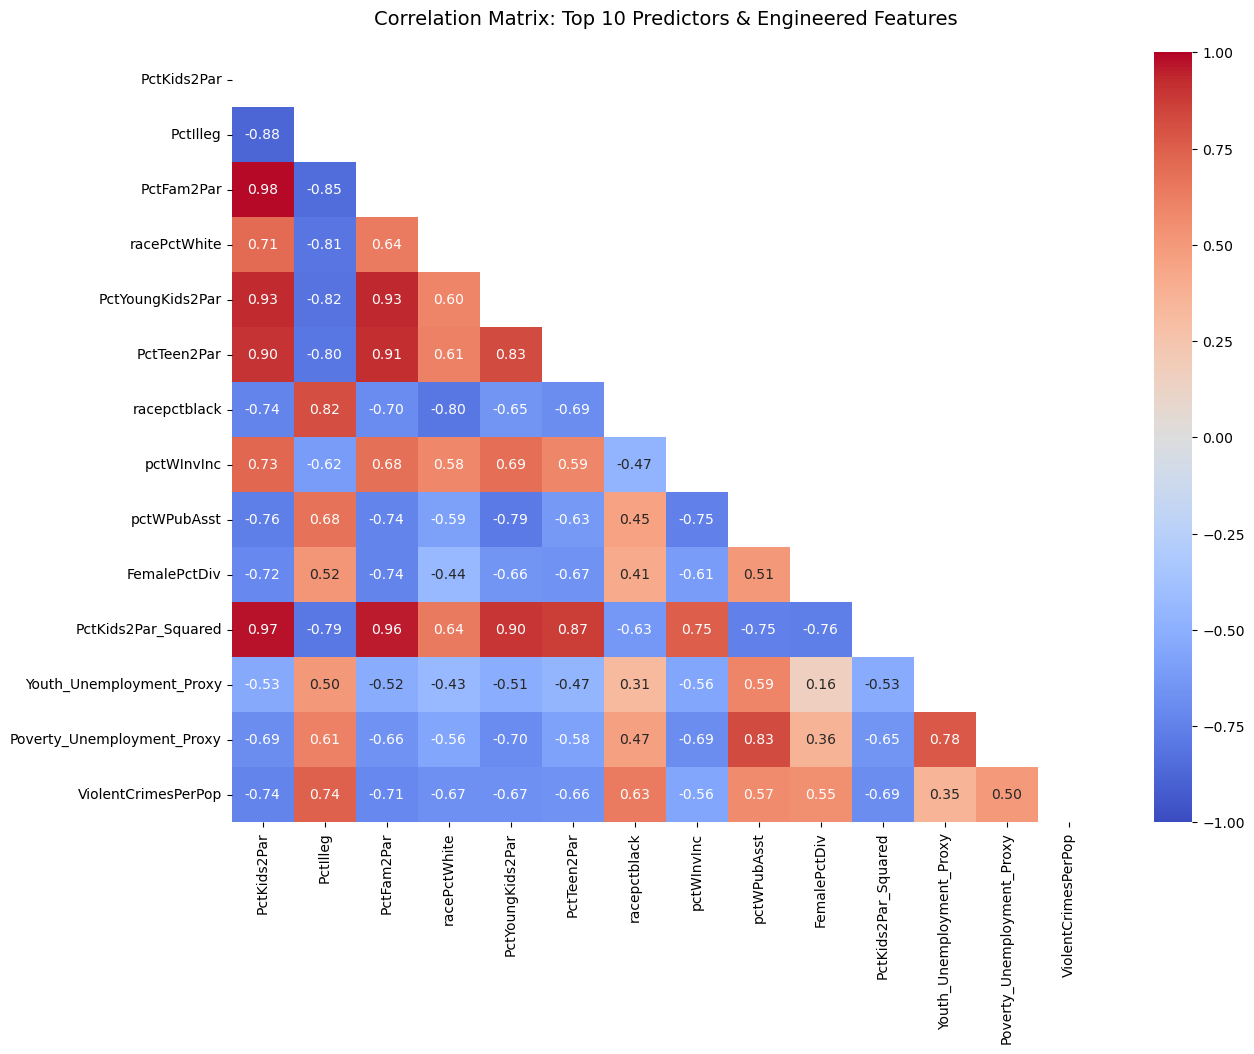

,mean,std,min,50%,max
PctKids2Par,0.615957,0.206465,0.000000,0.6300,0.990000
PctIlleg,0.250750,0.227854,0.000000,0.1700,1.299150
PctFam2Par,0.606700,0.201081,-0.014030,0.6200,0.990000
racePctWhite,0.755314,0.234484,-0.452499,0.8400,1.000000
PctYoungKids2Par,0.661874,0.215558,-0.006184,0.7000,1.000000
PctTeen2Par,0.577574,0.189681,0.009098,0.6000,1.000000
racepctblack,0.180020,0.252309,0.000000,0.0600,1.676259
pctWInvInc,0.493054,0.176711,0.000000,0.4800,1.000000
pctWPubAsst,0.314259,0.212660,0.000000,0.2600,1.054194
FemalePctDiv,0.493527,0.172675,0.000000,0.5100,0.930000


In [ ]:
# these feaures are selected based on Summary Statistics of "Correl" in communities.names. We presume higher "Correl" means stronger correlation with the target variable.
top_features = [
    'PctKids2Par', 'PctIlleg', 'PctFam2Par', 'racePctWhite', 'PctYoungKids2Par', 
    'PctTeen2Par', 'racepctblack', 'pctWInvInc', 'pctWPubAsst', 'FemalePctDiv',
    'PctKids2Par_Squared', 'Youth_Unemployment_Proxy', 'Poverty_Unemployment_Proxy'
]

subset_df = X_train[top_features].copy()
subset_df['ViolentCrimesPerPop'] = y_train

# in this plot, we visualize the correlation matrix of the top 10 predictors and the three engineered features. 
# This can help us understand the relationships between these features and identify any multicollinearity issues.
plt.figure(figsize=(14, 10))
corr_matrix = subset_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix: Top 10 Predictors & Engineered Features", fontsize=14, pad=20)
plt.show()

display(subset_df.describe().T[['mean', 'std', 'min', '50%', 'max']])

Task B: Regression Model Development and Evaluation

1. Model selection.
We adopt regression model here. For the model we have interacted with through course, regression models are more suitbale to deal with target variables that is numbers.
We tried rigid ,lasso and elstic net,and we choose elastic net as it is more flexable and thus have higher adapability comparing with rigid and lasso, especially we do not encounter computational restriction here as the data is simple.

In [ ]:
def evaluate_models(X_train, y_train, X_test, y_test):
    # Setup KFold for robust hyperparameter tuning
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    models_config = {
        'Ridge': (
            Ridge(random_state=42),
            {'alpha': [0.01, 0.1, 1.0, 5.0, 10.0]}
        ),
        'Lasso': (
            Lasso(max_iter=10000, tol=1e-3, random_state=42),
            {'alpha': [0.00001, 0.00005, 0.0001, 0.0005, 0.001]}
        ),
        'ElasticNet': (
            ElasticNet(max_iter=10000, tol=1e-3, random_state=42),
            {'alpha': [0.00001, 0.00005, 0.0001, 0.0005, 0.001], 
             'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}
        )
    }
    
    results = []
    
    for name, (model, params) in models_config.items():
        grid = GridSearchCV(model, params, cv=kf, scoring='r2')
        grid.fit(X_train, y_train)
        
        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)
        
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        
        results.append({
            'Model': name,
            'Best Params': str(grid.best_params_),
            'Test R2': round(r2, 4),
            'Test MSE': round(mse, 4)
        })
    
    return pd.DataFrame(results).sort_values(by='Test R2', ascending=False).reset_index(drop=True)

results_df = evaluate_models(X_train, y_train, X_test, y_test)

display(results_df)

,Model,Best Params,Test R2,Test MSE
0,ElasticNet,"{'alpha': 0.0005, 'l1_ratio': 0.9}",0.6411,0.0172


2. Discreticize the target and Fit two distinct classifiers.
here I discreticize the crime into high crime and low crime. For what is the criteria for high cirme rate, I consider to figure this out as a relative rather than abosolute, as relative crime rate can taken into consideration of the cultural of US society or other latent variables that affect the crime. here i specifically take the top 25% as high crime area, supported by The Pinkerton Crime Index.
From the experiment below, Decision Tree performs better, because here we use about 100 features, which is high dementional, making the distance calculation of KNN being less effective in our case.

In [ ]:
def build_and_evaluate_classifiers(X_train, y_train, X_test, y_test):
    # top 25% is high crime.
    threshold = y_train.quantile(0.75)
    
    # Convert continuous targets to integers (1 = High Crime, 0 = Low Crime)
    y_train_class = (y_train >= threshold).astype(int)
    y_test_class = (y_test >= threshold).astype(int)

    # still use k-fold for reobust hyperparameter tuning.
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    models_config = {
        'Decision Tree': (
            DecisionTreeClassifier(random_state=42),
            {'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 7, 10], 'criterion': ['gini', 'entropy']}
        ),
        'K-Nearest Neighbors': (
            KNeighborsClassifier(),
            {'n_neighbors': [3, 5, 7, 11, 15], 'weights': ['uniform', 'distance']}
        )
    }

    results = []
    best_models = {}
    
    for name, (model, params) in models_config.items():
        # Fit the model using F1-score optimization
        grid = GridSearchCV(model, params, cv=kf, scoring='f1')
        grid.fit(X_train, y_train_class)
        
        best_model = grid.best_estimator_
        best_models[name] = best_model
        
        y_pred = best_model.predict(X_test)
        
        f1 = f1_score(y_test_class, y_pred)
        recall = recall_score(y_test_class, y_pred)
        accuracy = accuracy_score(y_test_class, y_pred)
        
        results.append({
            'Model': name,
            'Best Params': str(grid.best_params_),
            'Test F1': round(f1, 4),
            'Test Recall': round(recall, 4),
            'Test Accuracy': round(accuracy, 4)
        })
        
    results_df = pd.DataFrame(results).sort_values(by='Test F1', ascending=False).reset_index(drop=True)

    return best_models, results_df

trained_classifiers, classification_results_df = build_and_evaluate_classifiers(X_train, y_train, X_test, y_test)

display(classification_results_df)

,Model,Best Params,Test F1,Test Recall,Test Accuracy
0,Decision Tree,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.6690,0.6419,0.8431
1,K-Nearest Neighbors,"{'n_neighbors': 11, 'weights': 'distance'}",0.6353,0.5473,0.8447


3. As shown by the hyper-parameter tuning process in 1. and 2. I tried mutiple hyper parameters on the same model. this could help finding the best hyper parameter that is able to catch the pattern of the featrues. With hyper-parameter tuning, the model performance had come to a accept level that the r2 for regression model is about 0.65 and the F1 score for classification model is about 0.65.


4. evalutaing model.
My favorate model is Decision Tree, as it has a Accuracy of 84%
1) For elastic net model, alpha control the strenght of regularization penalty, higher alpha will add bias and lower the variance. l1_ratio controls the impact share of Rigid and Lasso.
2) For decision tree model, increase of max depth as well as decrese of min_samples_split all increase the model's ability of catching pattern, lowering the bias, but in the same time higher the potential of catching noise.

Task C: Methodological & Substantive Implications

1. I am unsatisfied with my final result, as the r2 for regression model is lower than 70% and the F1 score for classification model is also lower than 0.7. I believe there can be improvements.
1) too many features to consider manually.

2. 
Advantages: with elastic net and decision tree, we are able to find the features that has most impact on predicting traget variable
Disadvantages: we simply use MICE and filter out features with more than 50% missing value. this could be treated more carefully as there can be systematical pattern of the missing value. What's more, I did not conduct feature conpressing like PCA, which may make the model performs worse as it rely more on prohaps useless features, but the benefit is that we make the model interpretable.

3. 
1) Firstly I will enrich the data, including more features, and find crime data that is more close to the time demographic survey is conducted. 
2) Secondly, I will taken into consideration of racial equlity factor.

4. This could be used as explaintary purpose for policy decision, for example, which place to allocate social aid resources. but this cannot be used in prediction of allocating police resource, as there is endogenity involved that more police deploied will also increase the crime found, thus resulting a bias away from communites that really need police.

5.
1) for racial equity issue, even filter out race data features, other factors will still contain related information.
2) the causal relation is not clear in this case. what clear is correlation. thus there could be much more to do if want to collect proof for a theory.

Question 2 – Tezpur University Android Malware Dataset